In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier


In [3]:
df = pd.read_csv("creditcard.csv")

print(df.head())
print(df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## Exploratory Data Analysis (EDA)

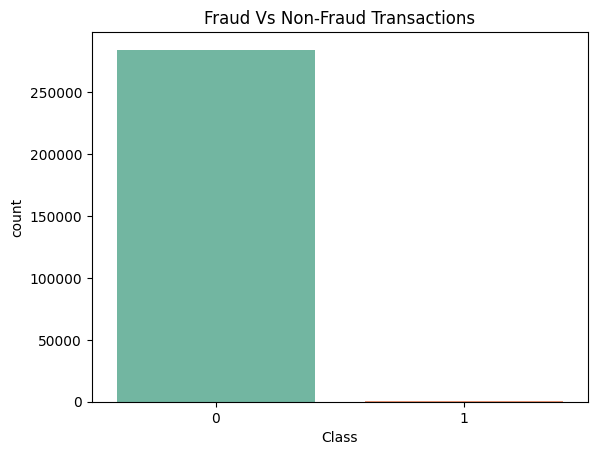

In [4]:
sns.countplot(x="Class", hue="Class", data=df, palette="Set2", legend=False)
plt.title("Fraud Vs Non-Fraud Transactions")
plt.show()

### Fraud vs Non-Fraud Transactions
Vast majority of transactions are non-fraudulent, with fraud cases <0.2%.

Highlights the class imbalance problem in fraud detection.

Accuracy alone is misleading; recall and precision are more meaningful.

Industry line: “Fraud detection is a rare-event challenge requiring specialized techniques like SMOTE and anomaly detection.”

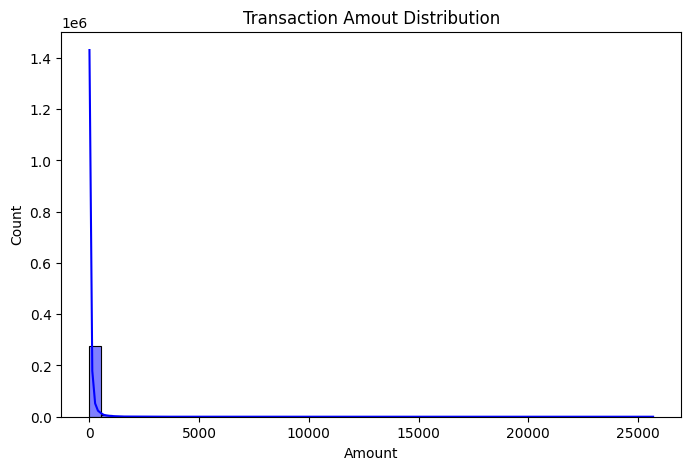

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins = 50, kde = True, color = 'blue')
plt.title("Transaction Amout Distribution")
plt.show()

### Transaction Amount Distribution
Most transactions are clustered at low amounts.

Very few high-value transactions, but they carry significant financial risk.

Fraud often occurs at extremes (tiny test charges or large theft attempts).

Risk-based authentication is essential for high-value transactions, while anomaly detection helps catch unusual low-value fraud attempts.

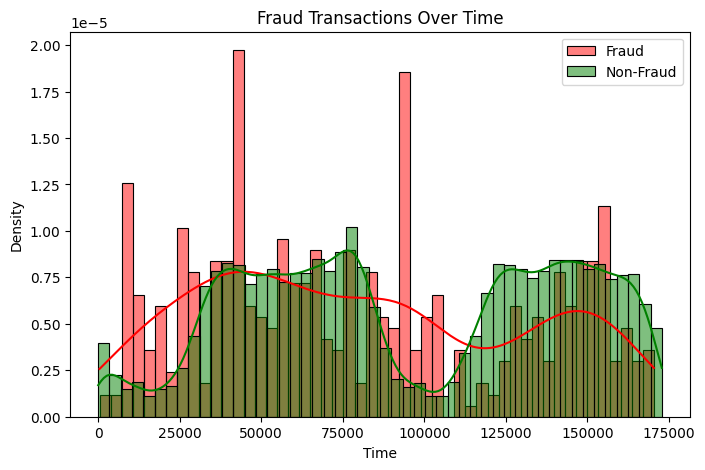

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['Class']==1]['Time'], bins = 50, color = "red", label = "Fraud", stat="density", kde=True)
sns.histplot(df[df['Class']==0]['Time'], bins = 50, color = "green", label = "Non-Fraud", stat="density", kde=True)
plt.legend()
plt.title("Fraud Transactions Over Time")
plt.show()

### Fraud Transactions Over Time
Non-fraud transactions are evenly distributed, while fraud shows spikes at specific times.

Fraudsters exploit unusual time windows (late night, off-peak hours).

Time-based features can improve fraud detection models.

Temporal analysis helps institutions identify fraud patterns and deploy real-time monitoring during high-risk periods.


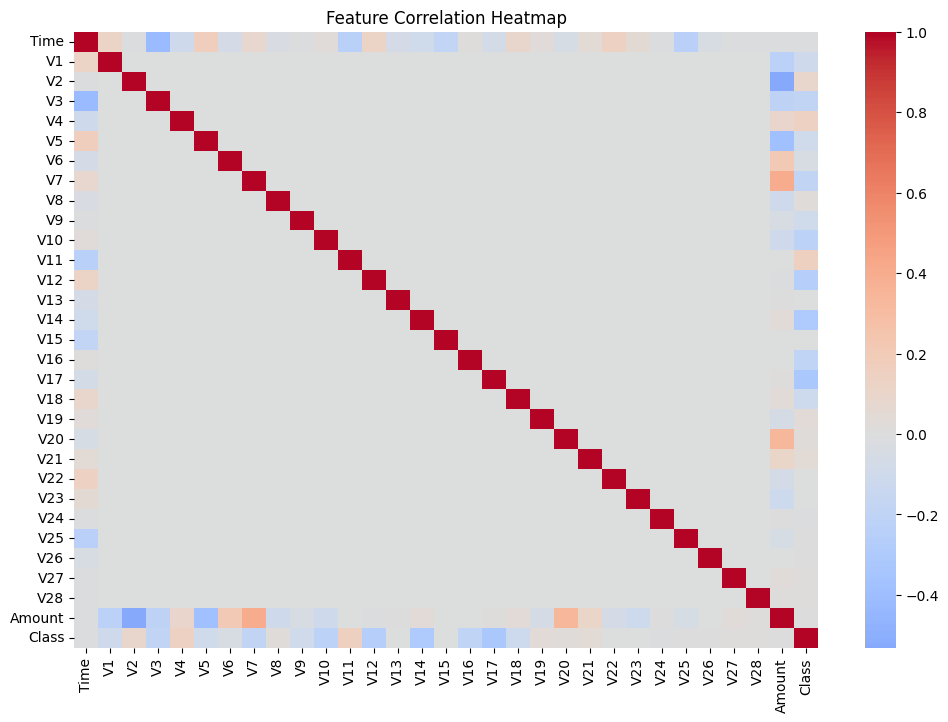

In [7]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center = 0)
plt.title("Feature Correlation Heatmap")
plt.show()

### Feature Correlation Heatmap
Certain anonymized features (V1–V28) show strong correlations with fraud.

Identifies which variables are most predictive for model training.

Helps reduce dimensionality and avoid multicollinearity.

Feature engineering guided by correlation analysis improves model efficiency and interpretability.

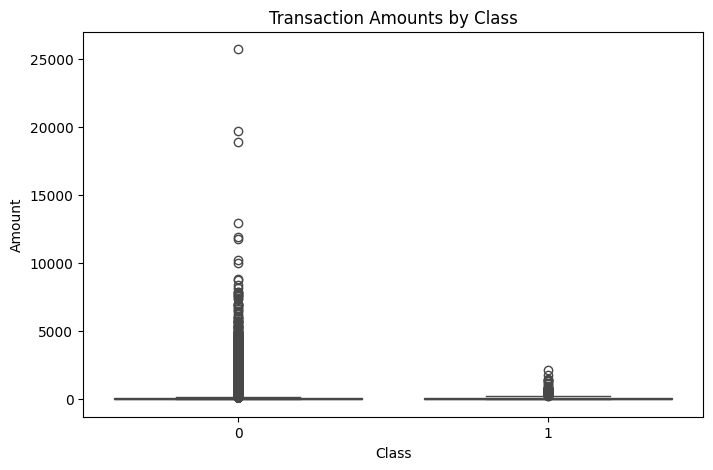

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df, hue="Class", palette="Set1", legend=False)
plt.title("Transaction Amounts by Class")
plt.show()

### Transaction Amounts by Class (Box Plot)
Non-fraud transactions span a wide range, including many high-value outliers.

Fraud transactions generally occur at lower amounts, but still show anomalies.

Distribution differences between classes provide useful predictive signals.

Industry line: “Outlier detection in transaction amounts is a key strategy for flagging suspicious activity.”

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

sm = SMOTE(random_state = 42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before Apply SMOTE:", y_train.value_counts())
print("After Apply SMOTE:", y_train_res.value_counts())

Before Apply SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After Apply SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


Before SMOTE → The dataset is highly imbalanced: ~227,451 non-fraud cases vs only 394 fraud cases. This imbalance makes models biased toward predicting “non-fraud” and ignoring rare fraud cases.

After SMOTE → Fraud cases have been synthetically oversampled to match non-fraud cases (227,451 each). Now the training data is balanced, giving the model equal opportunity to learn fraud patterns.

Techniques like SMOTE are standard in financial services to handle rare-event problems, making fraud detection models more reliable and regulator-compliant.

In [10]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

## Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train_res, y_train_res)
y_pred = rf.predict(X_test)

In [12]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



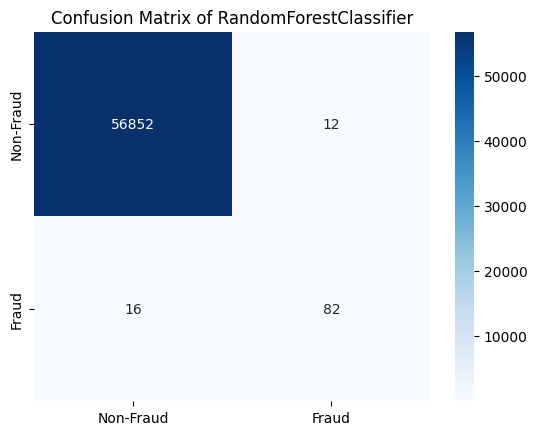

In [13]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix of RandomForestClassifier')
plt.show()

In [14]:
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC-AUC Score of RandomForestClassifier: {roc_auc: .4f}")

ROC-AUC Score of RandomForestClassifier:  0.9183


### Random Forest
Classification Report - Precision (Fraud) 0.87, Recall 0.84, F1-score 0.85.

Confusion Matrix - Very few false positives (12) and false negatives (16).

ROC-AUC - 0.9183.

Insight - Balanced performance, strong fraud detection with minimal false alarms.

## Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

logi = LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 42)
logi.fit(X_train_res, y_train_res)
y_pred_lr = logi.predict(X_test)

In [16]:
print("LogisticRegression Report:\n", classification_report(y_test, y_pred_lr))

LogisticRegression Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.92      0.28        98

    accuracy                           0.99     56962
   macro avg       0.58      0.96      0.64     56962
weighted avg       1.00      0.99      0.99     56962



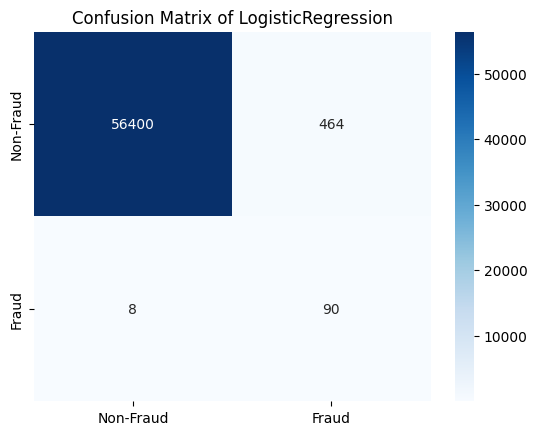

In [17]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix of LogisticRegression')
plt.show()

In [18]:
print("ROC-AUC of LogisticRegression:", roc_auc_score(y_test, y_pred_lr))

ROC-AUC of LogisticRegression: 0.95510376350878


### Logistic Regression
Classification Report - Precision (Fraud) 0.16, Recall 0.92, F1-score 0.28.

Confusion Matrix - High recall (90 frauds caught), but many false positives (464).

ROC-AUC - 0.955 (highest among models).

Insight - Excellent at catching fraud (high recall), but poor precision → too many false alarms, which can frustrate customers.

## XGBoost

In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators = 100, random_state = 42, eval_metric="logloss")
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_test)

In [20]:
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.84      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
print("ROC-AUC of XGBClassifier:", roc_auc_score(y_test, y_pred_xgb))

ROC-AUC of XGBClassifier: 0.9182178674790119


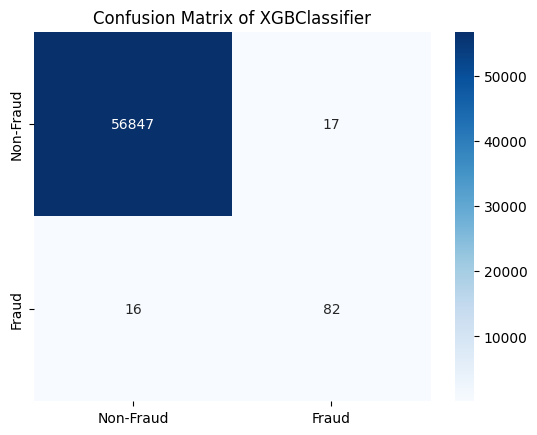

In [22]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix of XGBClassifier')
plt.show()

### XGBoost
Classification Report - Precision (Fraud) 0.83, Recall 0.84, F1-score 0.83.

Confusion Matrix - Few false positives (17) and false negatives (16).

ROC-AUC - 0.9182.

Insight - Similar to Random Forest, slightly lower precision but still strong. Efficient and widely used in fintech.

## Neural Network

In [23]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, 30), max_iter=50, random_state=42)
mlp.fit(X_train_res, y_train_res)
y_pred_mlp = mlp.predict(X_test)

In [24]:
print("Neural Network Report:\n", classification_report(y_test, y_pred_mlp))

Neural Network Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.81      0.78        98

    accuracy                           1.00     56962
   macro avg       0.88      0.90      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [25]:
print("ROC-AUC of Neural Network:", roc_auc_score(y_test, y_pred_mlp))

ROC-AUC of Neural Network: 0.9028326088454516


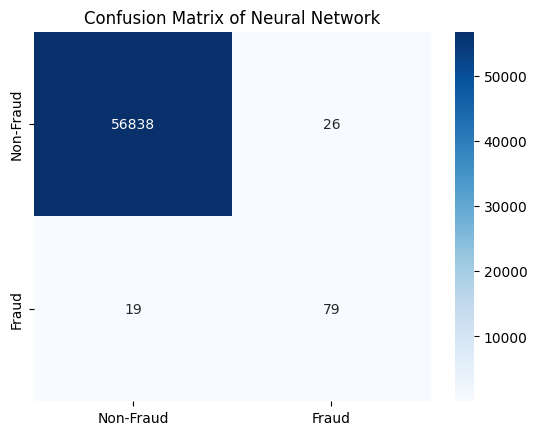

In [26]:
cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix of Neural Network')
plt.show()

### Neural Network
Classification Report - Precision (Fraud) 0.75, Recall 0.81, F1-score 0.78.

Confusion Matrix - More false positives (26) and false negatives (19) compared to Random Forest/XGBoost.

ROC-AUC - 0.9028 (lowest among models).

Insight - Decent performance, but weaker than tree-based models and less interpretable for compliance.

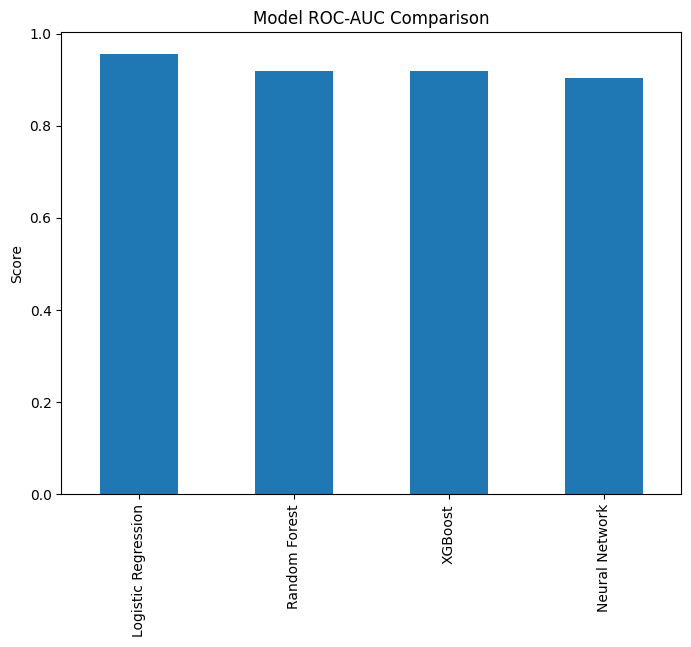

In [27]:
results = {
    "Logistic Regression": [roc_auc_score(y_test, y_pred_lr)],
    "Random Forest": [roc_auc_score(y_test, y_pred)],
    "XGBoost": [roc_auc_score(y_test, y_pred_xgb)],
    "Neural Network": [roc_auc_score(y_test, y_pred_mlp)]
}

results_df = pd.DataFrame(results, index=["ROC-AUC"]).T
results_df.plot(kind="bar", figsize=(8,6), legend=False)
plt.title("Model ROC-AUC Comparison")
plt.ylabel("Score")
plt.show()


### Logistic Regression vs Random Forest - 
Logistic Regression has higher recall and ROC-AUC, but precision is very poor (many false alarms). Random Forest balances both precision and recall, making it more practical.

### Random Forest vs XGBoost - 
Both are strong, but Random Forest edges ahead with slightly better precision and interpretability.

### Tree-Based Models vs Neural Network - 
Neural Network performs reasonably but lags behind in precision, recall, and ROC-AUC. Tree-based models are easier to explain to regulators.

## Conclusion

Logistic Regression - Good baseline, but not production-ready due to false alarms.

Random Forest - Best balance, interpretable, regulator-friendly, strong fraud detection.

XGBoost - Competitive, efficient, but slightly less interpretable.

Neural Network - Useful for complex patterns, but weaker metrics and harder to explain.

#### Best Model: Random Forest

Reason: It achieves the strongest balance between fraud detection (recall) and minimizing false alarms (precision).

Industry Fit: Tree-based models are widely deployed in banking/fintech because they are robust, interpretable, and regulator-compliant.

## Final Recommendation:
Deploy Random Forest as the primary fraud detection model. It balances customer convenience (low false alarms) with risk management (high fraud detection), and its interpretability makes it ideal for industry use.